In [ ]:
import numpy as np
from sim_library.constants import k_eff, dR, m, kb, omega_eg
from scipy.constants import hbar, pi
import matplotlib.pyplot as plt
from pathlib import Path
from sim_library.simulation import simulate_pulses_single_atom, simulate_pulses_single_atom_analyt, simulate_pulses_p_dist, simulate_alg_cooling, simulate_alg_cooling_custom
from sim_library.sequences import RR3_gate, PulseSequence, UpPulse, DownPulse, FreeEvolution, gen_MDFEup_seq, gen_MDFEdown_seq, RR3_adjMDFE_500kHz, RR3_phasecomp_500kHz, swap23_gate
from sim_library.plotting import plot_state_trajectories, plot_bloch, plot_hist, save_gif, plot_coolingcycles_22, fit_gaussian, fit_gaussian_custom, display_table_compare, plot_bloch_multi
from sim_library.data_io import load_p_dists

### Test gate fidelity

In [97]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1000

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

detuning = omega_eg/2
free_time = 2*pi/(np.abs(dR-detuning))

lamda = 0.039258728343342396
F_MDFE = 1.5064264264264264*free_time/2 - (free_time/8)
F_quartpi = (0.0098281 - (lamda/4))*free_time/2
G_MDFE = 0.6267267267267267*pi/dR
G_quartpi = (lamda/4)*pi/dR
MDFE_time = G_MDFE - (2*G_quartpi)
if MDFE_time<=0:
    print('MDFE duration is negative!')
    
# MDFE = gen_MDFEdown_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=n_steps, detuning=dR)
MDFE = gen_MDFEdown_seq(free_time=MDFE_time, rabi_freq=rabi_freq, time_steps=n_steps, detuning=0)

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 0
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
    pulse_seq1 = PulseSequence()

    pulse1 = UpPulse(laser_det=np.full(n_steps,0),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/(4))

    free1 = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=F_MDFE)
    free2 = FreeEvolution(laser_det=(np.full(n_steps, detuning)), duration=2*F_quartpi)
    

    pulse_seq1.add_pulses([pulse1, free1, free2, MDFE, pulse1])

    wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

    if i == 0:
        wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

    wave_funcs[i,:,:] = wave_func[:,indices[i]:indices[i]+2]


angles = (np.angle(wave_funcs[:,:,1]) - np.angle(wave_funcs[:,:,0]))

angles = np.unwrap(angles, axis=1)

# fig, ax = plt.subplots()
# ax.plot(times/(rabi_time),angles.transpose()/pi)
# # ax.set_yticks([0,0.02,0.04,0.06,0.08,0.1,0.12],[r'0.00', r'0.02$\pi$', r'0.04$\pi$', r'0.06$\pi$', r'0.08$\pi$', r'0.1$\pi$', r'0.12$\pi$'])
# # ax.set_ylim(-0.005,0.12)
# ax.grid()
# ax.set_ylabel(r'Relative phase evolved (rad)')
# ax.set_xlabel(r'Time elapsed ($t_{2\pi}$)')
# ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'])
# ax.set_title('500kHz')
# # plt.ylim(0,2.1)
# # plt.xlim(0,(rabi_time/2)*1.1)

print(angles[:,-1]/pi)
target_states = np.zeros((len(indices), 2), dtype=np.complex128)
target_states[0] = np.array([0,1], dtype=np.complex128)
target_states[1] = np.array([1,0], dtype=np.complex128)
target_states[2] = np.array([0,1], dtype=np.complex128)
target_states[3] = np.array([1,0], dtype=np.complex128)
# target_states[0] = np.array([1/np.sqrt(2),np.exp(1j*0.25*pi)*1/np.sqrt(2)], dtype=np.complex128)
# target_states[1] = np.array([1/np.sqrt(2),np.exp(1j*1.25*pi)*1/np.sqrt(2)], dtype=np.complex128)
# target_states[2] = np.array([1/np.sqrt(2),np.exp(1j*0.25*pi)*1/np.sqrt(2)], dtype=np.complex128)
# target_states[3] = np.array([1/np.sqrt(2),np.exp(1j*1.25*pi)*1/np.sqrt(2)], dtype=np.complex128)
sum = 0
fids = []
for i in range(len(indices)):
    fid_temp = np.abs(np.vdot(wave_funcs[i,-1,:],target_states[i,:]))**2
    sum += fid_temp
    fids.append(fid_temp)
fidelity = sum/len(indices)
print(fids)
print(fidelity)



# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)

[2.3175206  3.8985455  4.71374706 4.3542575 ]
[0.9912893229774451, 0.9085850565724726, 0.9023919411625463, 0.8168521698083284]
0.9047796226301981


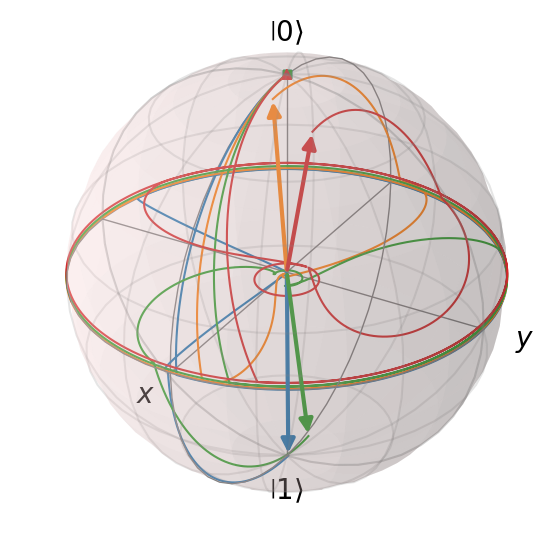

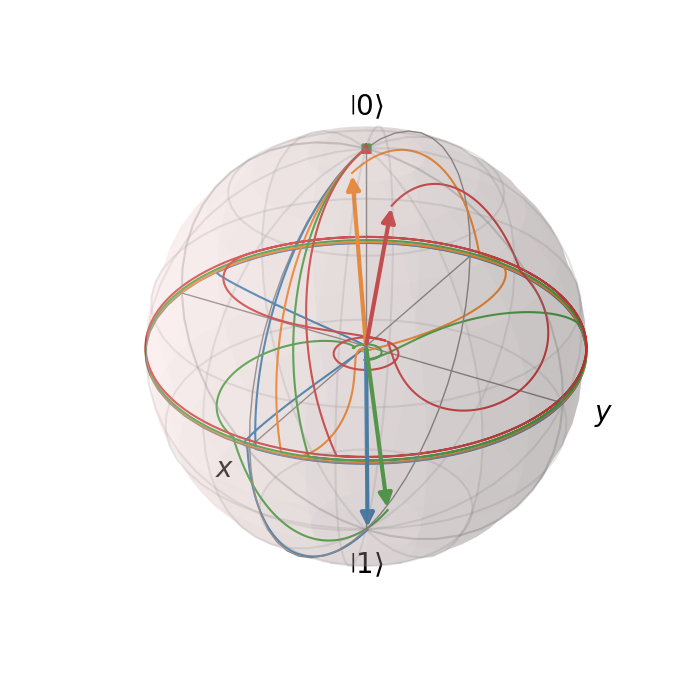

In [38]:
%matplotlib widget
b, fig = plot_bloch_multi(wave_func=wave_funcs, show=True)
fig


In [29]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1

indices = [8,10,12,14]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)

target_states = np.zeros((len(indices), 2), dtype=np.complex128)
target_states[0] = np.array([0,1], dtype=np.complex128)
target_states[1] = np.array([1,0], dtype=np.complex128)
target_states[2] = np.array([0,1], dtype=np.complex128)
target_states[3] = np.array([1,0], dtype=np.complex128)

MDFE_times = np.linspace(0*pi/dR, 2*pi/dR, 1000)
detuning = omega_eg/2
free_time = 2*pi/(np.abs(dR-detuning))
free_times = np.linspace(0,free_time, 1000)

fidelities = np.zeros((len(indices),len(free_times),len(MDFE_times)))
# fid_sum = np.zeros(len(free_times))

# Set doppler shift
atom_veloc = 0.0 # Stationary

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 0
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

    for t1, time1 in enumerate(free_times):
        for t2, time2 in enumerate(MDFE_times):
            pulse_seqq = PulseSequence()

            pulse1 = UpPulse(laser_det=np.full(n_steps,dR),phase=np.full(n_steps, pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/4)
            free = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=(time1))
            MDFE = gen_MDFEdown_seq(free_time=time2, rabi_freq=rabi_freq, time_steps=n_steps, detuning=dR)
            pulse_seqq.add_pulses([pulse1, free, MDFE, pulse1])
            wave_func, _ = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seqq, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

            fidelity = np.abs(np.vdot(wave_func[-1, indices[i]:indices[i]+2],target_states[i,:]))**2
            fidelities[i, t1, t2] = fidelity
        


### Average fidelity ###
fid_sum = np.sum(fidelities, axis=0)/len(indices)
# print(free_times[np.argmax(fid_sum)]*dR/pi)
# print(np.max(fid_sum))
# fig, ax = plt.subplots()
# ax.plot(free_times*dR/pi,fid_sum)



# ax.set_ylim(0,1.05)
# ax.set_xlim(free_times[0]*dR/pi, free_times[-1]*dR/pi)
# ax.set_xlabel(r'$t$ $(\pi/\delta_R)$')
# ax.set_ylabel('Averaged Fidelity')
# ax.set_title(r'$G_+(\pi/4)$ time scan at 500kHz')
# ax.grid()
# ######




Text(0, 0.5, 'F duration')

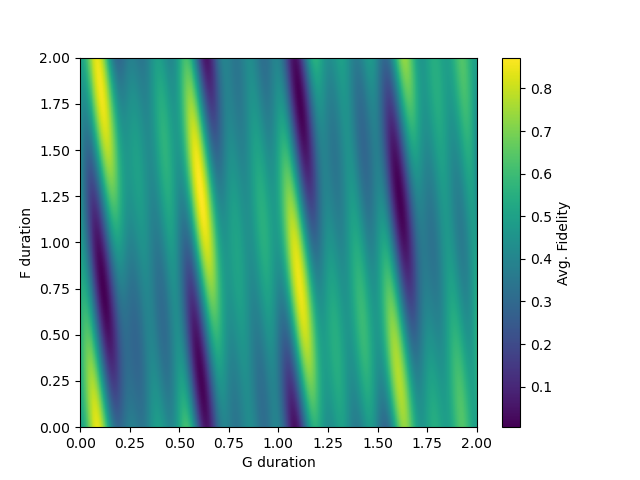

In [30]:
fig, ax = plt.subplots()
pc = ax.pcolormesh(MDFE_times*dR/pi, free_times*2/free_time, fid_sum, shading='auto', cmap='viridis')
fig.colorbar(pc, ax=ax, label='Avg. Fidelity')
ax.set_xlabel('G duration'); ax.set_ylabel('F duration')

### EX10

In [9]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1000

indices = [9,11,13]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

detuning = omega_eg/2
free_time = 2*pi/(np.abs(dR-detuning))

lamda = 0.039258728343342396
F_MDFE = 0.5527227227227227*free_time/2 - (5*free_time/8)
F_quartpi = (0.0098281 - (lamda/4))*free_time/2
G_MDFE = 1.6307607607607606*pi/dR
G_quartpi = (lamda/4)*pi/dR
MDFE_time = G_MDFE - (2*G_quartpi)
if MDFE_time<=0:
    print('MDFE duration is negative!')
    
MDFE = gen_MDFEup_seq(free_time=pi/(4*dR), rabi_freq=rabi_freq, time_steps=n_steps, detuning=0)
# MDFE = gen_MDFEup_seq(free_time=MDFE_time, rabi_freq=rabi_freq, time_steps=n_steps, detuning=0)

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 0
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise
    pulse_seq1 = PulseSequence()

    pulse1 = DownPulse(laser_det=np.full(n_steps,0),phase=np.full(n_steps, -pi/2), rabi_freq=np.full(n_steps,rabi_freq), duration=rabi_time/(4))

    free1 = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=F_MDFE)
    free2 = FreeEvolution(laser_det=(np.full(n_steps, -detuning)), duration=3*free_time/8)
    

    pulse_seq1.add_pulses([pulse1, free2, MDFE, pulse1])

    wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=pulse_seq1, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

    if i == 0:
        wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

    wave_funcs[i,:,:] = wave_func[:,indices[i]:indices[i]+2]


angles = (np.angle(wave_funcs[:,:,1]) - np.angle(wave_funcs[:,:,0]))

angles = np.unwrap(angles, axis=1)

# fig, ax = plt.subplots()
# ax.plot(times/(rabi_time),angles.transpose()/pi)
# # ax.set_yticks([0,0.02,0.04,0.06,0.08,0.1,0.12],[r'0.00', r'0.02$\pi$', r'0.04$\pi$', r'0.06$\pi$', r'0.08$\pi$', r'0.1$\pi$', r'0.12$\pi$'])
# # ax.set_ylim(-0.005,0.12)
# ax.grid()
# ax.set_ylabel(r'Relative phase evolved (rad)')
# ax.set_xlabel(r'Time elapsed ($t_{2\pi}$)')
# ax.legend([r'$n=0,1$',r'$n=2,3$',r'$n=4,5$',r'$n=6,7$'])
# ax.set_title('500kHz')
# # plt.ylim(0,2.1)
# # plt.xlim(0,(rabi_time/2)*1.1)

print(angles[:,-1]/pi)
target_states = np.zeros((len(indices), 2), dtype=np.complex128)
target_states[0] = np.array([0,1], dtype=np.complex128)
target_states[1] = np.array([1,0], dtype=np.complex128)
target_states[2] = np.array([0,1], dtype=np.complex128)
# target_states[0] = np.array([1/np.sqrt(2),np.exp(1j*0.75*pi)*1/np.sqrt(2)], dtype=np.complex128)
# target_states[1] = np.array([1/np.sqrt(2),np.exp(1j*1.75*pi)*1/np.sqrt(2)], dtype=np.complex128)
# target_states[2] = np.array([1/np.sqrt(2),np.exp(1j*0.75*pi)*1/np.sqrt(2)], dtype=np.complex128)
sum = 0
fids = []
for i in range(len(indices)):
    fid_temp = np.abs(np.vdot(wave_funcs[i,-1,:],target_states[i,:]))**2
    sum += fid_temp
    fids.append(fid_temp)
fidelity = sum/len(indices)
print(fids)
print(fidelity)



# display_table_compare(basis=basis, init_state=wave_func[0,:], final_state=wave_func[-1,:])
# plot_bloch(wave_func=wave_func[:,indices[0]:indices[1]+1], show=True)

[-1.47634163 -0.11608832  1.69191776]
[0.6114504414187504, 0.005209029370231566, 0.36909914311288927]
0.3285862046339571


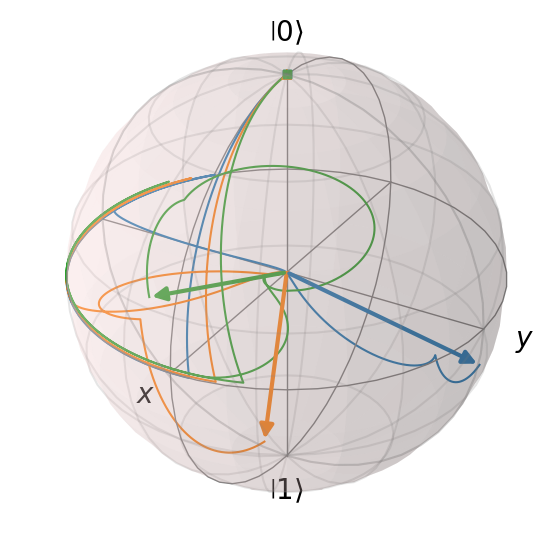

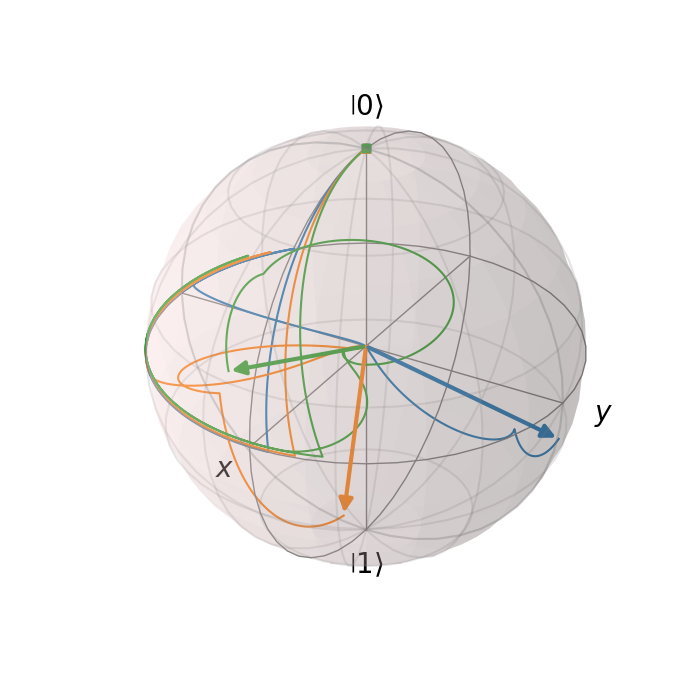

In [10]:
%matplotlib widget
b, fig = plot_bloch_multi(wave_func=wave_funcs, show=True)
fig


### RR3

In [ ]:

# Rabi frequency in 2*pi*Hz units
rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq # 2pi pulse time

# Set total resolution of time steps
n_steps = 1000

indices = [9,11,13]

# Define basis: p in units of hbar*k (even p = ground state)
p_min = -8
p_max = 8
basis = np.arange(p_min, p_max + 1)


# Set doppler shift
atom_veloc = 0.0 # Stationary

### SWAP23

In [24]:
detuningfree = omega_eg/2
detuning = 0

time_steps = 100

rabi_freq = 2*pi*5e5
rabi_time = 2*pi/rabi_freq
free_time = 2*pi/(np.abs(dR-detuningfree))

indices = [8,10,12,14]

atom_veloc=0

lamda = 0.039258728343342396
F_bs = (0.0098281 - (lamda/4))*free_time/2
G_bs = (lamda/4)*pi/dR

F_MDFE_quartpi_down = 1.5064264264264264*free_time/2
G_MDFE_quartpi_down = 0.6267267267267267*pi/dR

F_MDFE_quartpi_up = 0.5527227227227227*free_time/2
G_MDFE_quartpi_up = 1.6307607607607606*pi/dR

F_MDFE_eighthpi_down = 0.032532532532532535*free_time/2
G_MDFE_eighthpi_down = 0.0*pi/dR

F_MDFE_eighthpi_up = 1.972172172172172*free_time/2
G_MDFE_eighthpi_up = 0.0*pi/dR

swap23 = PulseSequence()
pulse_1 = UpPulse(laser_det=np.full(time_steps, detuning), phase=np.full(time_steps, 0), rabi_freq=np.full(time_steps, rabi_freq), duration=rabi_time/4) # up pi/2, phi=0
MDFE_1 = gen_MDFEdown_seq(free_time=G_MDFE_eighthpi_down-(2*G_bs), rabi_freq=rabi_freq, time_steps=time_steps, detuning=detuning) # pi/8
MDFE_2 = gen_MDFEdown_seq(free_time=G_MDFE_eighthpi_down, rabi_freq=rabi_freq, time_steps=time_steps, detuning=detuning) # pi/8
freevolve_1 = FreeEvolution(laser_det=(np.full(time_steps, -detuningfree)), duration=(7*free_time/16)+F_MDFE_eighthpi_down-(2*F_bs)) # 7pi/8
freevolve_2 = FreeEvolution(laser_det=(np.full(time_steps, -detuningfree)), duration=(3*free_time/16)+F_MDFE_eighthpi_down) # 3pi/8
swap23.add_pulses([pulse_1,
                    freevolve_1,
                    MDFE_1,
                    pulse_1,
                    freevolve_2,
                    MDFE_2,
                    pulse_1,
                    freevolve_1,
                    MDFE_1,
                    pulse_1
                    ])

for i in range(len(indices)):
    initial_state = np.zeros(shape=len(basis), dtype=np.complex128)
    initial_state[indices[i]] = 1
    initial_state[indices[i]+1] = 0
    initial_state = initial_state/ np.linalg.norm(initial_state) # Normalise

    wave_func, times = simulate_pulses_single_atom_analyt(pulse_seq=swap23, basis=basis, initial_state=initial_state, d_shift=k_eff*atom_veloc)

    if i == 0:
        wave_funcs = np.zeros((len(indices),len(times),2), dtype=np.complex128)

    wave_funcs[i,:,:] = wave_func[:,indices[i]:indices[i]+2]


target_states = np.zeros((len(indices), 2), dtype=np.complex128)
target_states[0] = np.array([1,0], dtype=np.complex128)
target_states[1] = np.array([0,1], dtype=np.complex128)
target_states[2] = np.array([1,0], dtype=np.complex128)
target_states[3] = np.array([1,0], dtype=np.complex128)
sum = 0
fids = []
for i in range(len(indices)):
    fid_temp = np.abs(np.vdot(wave_funcs[i,-1,:],target_states[i,:]))**2
    sum += fid_temp
    fids.append(fid_temp)
fidelity = sum/len(indices)
print(fids)
print(fidelity)
print(wave_funcs[:,-1,:])

[0.9944835645719075, 0.9556059527513702, 0.9574388722935926, 0.7558197110144198]
0.9158370251578225
[[-0.9425897 -0.32558905j  0.06918002-0.0248674j ]
 [ 0.05790757-0.19391063j -0.68994236-0.69252112j]
 [-0.50833291+0.83608404j -0.0086257 -0.04154916j]
 [ 0.71574516-0.49348615j -0.08614507-0.27979951j]]


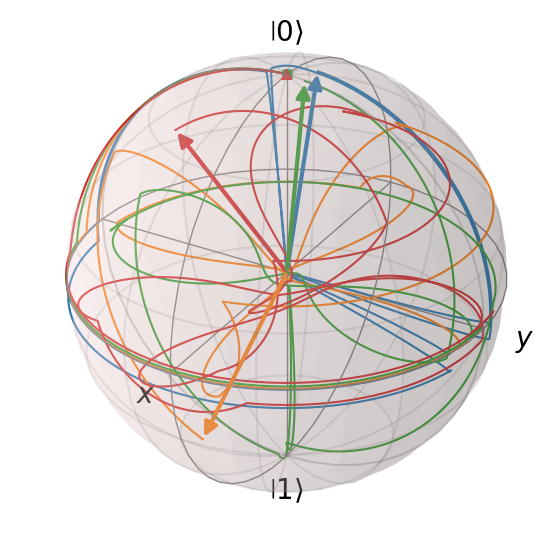

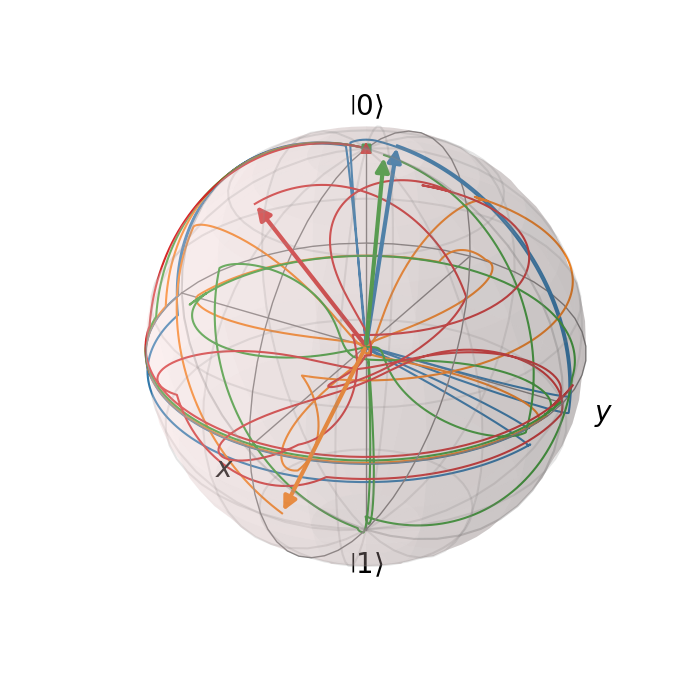

In [28]:
%matplotlib widget
b, fig = plot_bloch_multi(wave_func=wave_funcs, show=True)
fig